# Serie de tiempo de flujo solar
### María José Soto Castro A01705840


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
flux_path = '/content/drive/MyDrive/solarFlux/solar_flux_table.txt'

In [ ]:
df = pd.read_csv(flux_path,
            sep=r"\s+",          # separa por múltiples espacios
            skiprows=[1])     # ignora la línea de guiones)

Se inicia con el formateo de fechas, las columnas que indican tiempo en este dataset son 4:
- Fluxdate: fecha gregoriana de la medición
- Fluxtime: tiempo con reloj atómico o mundial
- fluxjulian: fecha juliana utilizada para interpretar trancisiones de cielo observable
- Fluxcarrington: fecha descrita en no. de rotaciones que ha hecho el sol desde 9 de noviembre del 1853.

In [ ]:

# Convertir columnas numéricas
cols = [
    "fluxjulian",
    "fluxcarrington",
    "fluxobsflux",
    "fluxadjflux",
    "fluxursi"
]

df[cols] = df[cols].astype(float)

print(df.dtypes)

fluxdate            int64
fluxtime            int64
fluxjulian        float64
fluxcarrington    float64
fluxobsflux       float64
fluxadjflux       float64
fluxursi          float64
dtype: object


In [ ]:
df.head()

,fluxdate,fluxtime,fluxjulian,fluxcarrington,fluxobsflux,fluxadjflux,fluxursi
0,20041028,170000,2453307.229,2022.605,132.7,130.9,117.8
1,20041028,200000,2453307.354,2022.610,135.8,134.0,120.6
2,20041029,200000,2453308.354,2022.646,130.6,128.8,115.9
3,20041029,230000,2453308.479,2022.651,134.2,132.3,119.1
4,20041030,170000,2453309.229,2022.678,147.9,145.8,131.2


In [ ]:
#Cambiar formato de fecha en fluxdate

df["fluxdate"] = pd.to_datetime(
    df["fluxdate"].astype(str),
    format="%Y%m%d"
)

print(df["fluxdate"].head())

0   2004-10-28
1   2004-10-28
2   2004-10-29
3   2004-10-29
4   2004-10-30
Name: fluxdate, dtype: datetime64[ns]


In [ ]:
#Cambiar formato de tiempo en fluxtime

df["datetime"] = pd.to_datetime(
    df["fluxdate"].dt.strftime("%Y-%m-%d") +
    " " +
    df["fluxtime"].astype(str).str.zfill(6),
    format="%Y-%m-%d %H%M%S"
)

print(df["datetime"].head())

0   2004-10-28 17:00:00
1   2004-10-28 20:00:00
2   2004-10-29 20:00:00
3   2004-10-29 23:00:00
4   2004-10-30 17:00:00
Name: datetime, dtype: datetime64[ns]


In [ ]:
df.head()

,fluxdate,fluxtime,fluxjulian,fluxcarrington,fluxobsflux,fluxadjflux,fluxursi,datetime
0,2004-10-28,170000,2453307.229,2022.605,132.7,130.9,117.8,2004-10-28 17:00:00
1,2004-10-28,200000,2453307.354,2022.610,135.8,134.0,120.6,2004-10-28 20:00:00
2,2004-10-29,200000,2453308.354,2022.646,130.6,128.8,115.9,2004-10-29 20:00:00
3,2004-10-29,230000,2453308.479,2022.651,134.2,132.3,119.1,2004-10-29 23:00:00
4,2004-10-30,170000,2453309.229,2022.678,147.9,145.8,131.2,2004-10-30 17:00:00


In [ ]:
df.count()

,0
fluxdate,23595
fluxtime,23595
fluxjulian,23595
fluxcarrington,23595
fluxobsflux,23595
fluxadjflux,23595
fluxursi,23595
datetime,23595


Las columnas de fluxobs, fluxadj y fluxursi son estandarizaciones diferentes del mismo dato de flujo solar. Es necesario utilizar estos 3 para utilizarlos en la astronomía, debido a la variación de instrumentos donde se utilizan.


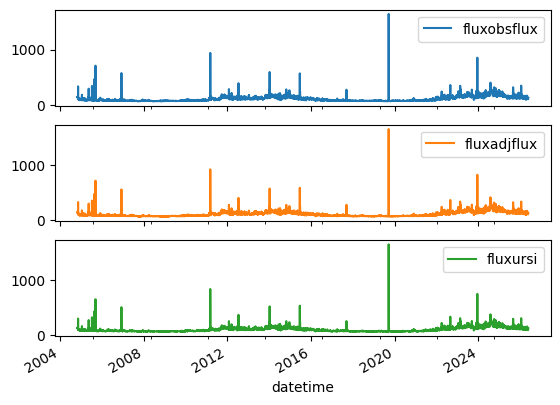

In [ ]:
plot_cols = ['fluxobsflux', 'fluxadjflux', 'fluxursi']
plot_features = df[plot_cols]
plot_features.index = df['datetime']
_ = plot_features.plot(subplots=True)




> Se realizan tres mediciones de flujo cada día. Entre marzo y octubre, las mediciones se realizan a las 17:00, 20:00 (mediodía local) y 23:00 UT. Sin embargo, la ubicación en un valle de montaña y una latitud relativamente alta imposibilitan mantener estos horarios durante el resto del año. Por consiguiente, de noviembre a febrero, las mediciones de flujo se realizan a las 18:00, 20:00 y 22:00, para que el Sol esté lo suficientemente alto sobre el horizonte y se pueda realizar una buena medición. (Canada, 2019)



In [ ]:
# Crear lags
# 1 día atrás. Cada dia tiene 3 registros
df["lag_day"] = df["fluxadjflux"].shift(3)

# 1 semana atrás
df["lag_week"] = df["fluxadjflux"].shift(21)

# Rotación solar (~27 días)
df["lag_solar_rotation"] = df["fluxadjflux"].shift(81)

# 1 mes atrás
df["lag_month"] = df["fluxadjflux"].shift(90)

# 3 meses atrás
df["lag_3months"] = df["fluxadjflux"].shift(270)

# 1 año atrás
df["lag_year"] = df["fluxadjflux"].shift(1095)

# Eliminar NaNs generados por los lags
df = df.dropna().reset_index(drop=True)

In [ ]:
df.head()

,fluxdate,fluxtime,fluxjulian,fluxcarrington,fluxobsflux,fluxadjflux,fluxursi,datetime,lag_day,lag_week,lag_solar_rotation,lag_month,lag_3months,lag_year
0,2005-11-05,200000,2453680.337,2036.284,79.3,77.9,70.1,2005-11-05 20:00:00,76.1,73.1,78.7,79.4,94.9,130.9
1,2005-11-05,220000,2453680.421,2036.288,80.9,79.5,71.6,2005-11-05 22:00:00,77.6,74.3,79.2,79.5,95.6,134.0
2,2005-11-06,180000,2453681.254,2036.318,80.6,79.1,71.2,2005-11-06 18:00:00,76.6,73.9,78.8,78.1,89.3,128.8
3,2005-11-06,200000,2453681.337,2036.321,81.7,80.3,72.3,2005-11-06 20:00:00,77.9,74.5,78.8,78.7,88.9,132.3
4,2005-11-06,220000,2453681.421,2036.324,82.4,80.9,72.8,2005-11-06 22:00:00,79.5,75.7,79.4,79.1,88.9,145.8


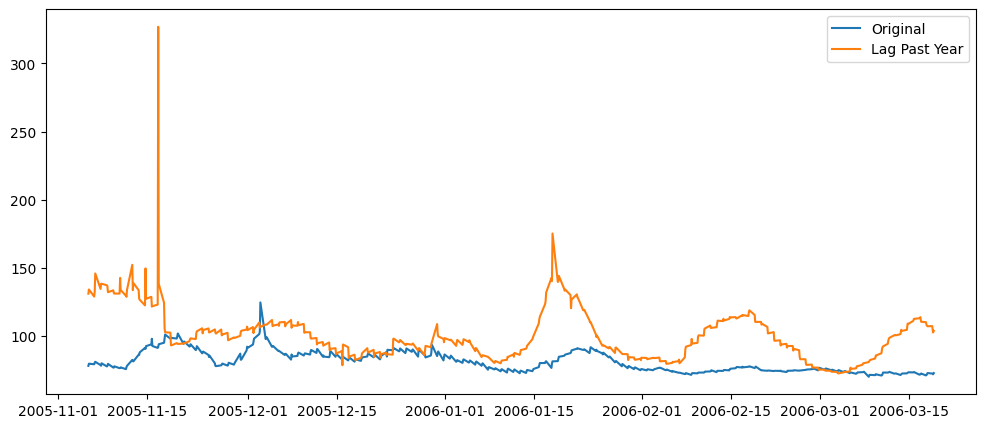

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df["datetime"][:400], df["fluxadjflux"][:400], label="Original")
plt.plot(df["datetime"][:400], df["lag_year"][:400], label="Lag Past Year")

plt.legend()
plt.show()

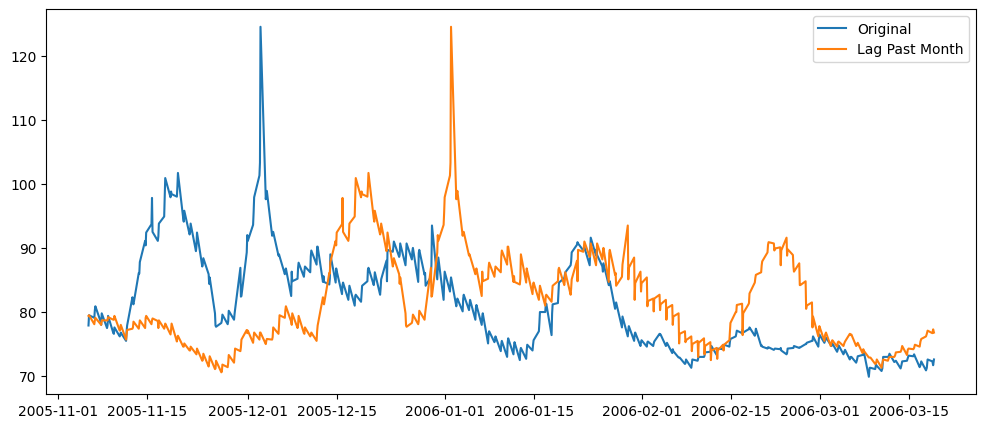

In [ ]:

plt.figure(figsize=(12,5))

plt.plot(df["datetime"][:400], df["fluxadjflux"][:400], label="Original")
plt.plot(df["datetime"][:400], df["lag_month"][:400], label="Lag Past Month")

plt.legend()
plt.show()

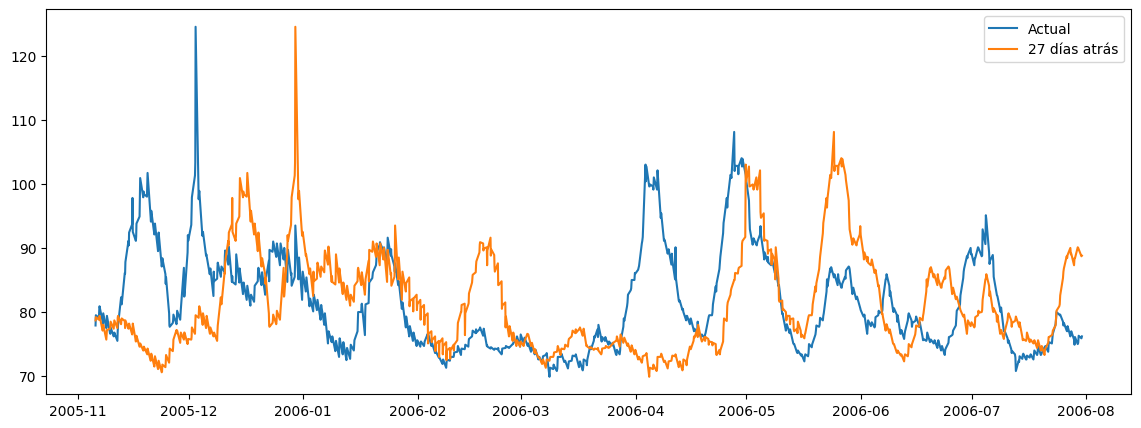

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(df["datetime"][:800], df["fluxadjflux"][:800], label="Actual")
plt.plot(df["datetime"][:800], df["lag_solar_rotation"][:800],
         label="27 días atrás")

plt.legend()
plt.show()

# DATA SPLITTING

In [ ]:
n = len(df)
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

num_features = df.shape[1]

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(15749, 14)
(4501, 14)
(2250, 14)


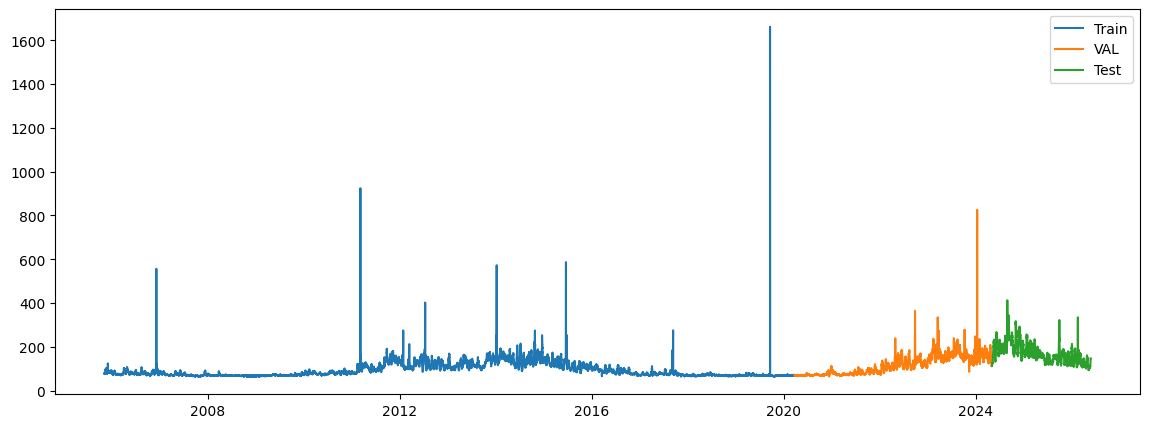

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(train_df["datetime"], train_df["fluxadjflux"], label="Train")
plt.plot(val_df["datetime"], val_df["lag_solar_rotation"],
         label="VAL")
plt.plot(test_df["datetime"], test_df["lag_solar_rotation"],
         label="Test")


plt.legend()
plt.show()

# Normalisación de datos
Para normalizar los datos, se aplica RobustScaler de sklearn, debido a la fluctuación de datos extrema en flujo solar en vez de utilizar los percentiles de 25% y 75% y la mediana para prevenir perder los datos extremos.

A comparación de min-max o con desviación estandar, los picos en los datos no son erradicados.

In [ ]:

features = [
    "fluxobsflux",
    "fluxadjflux",
    "fluxursi",
    "lag_day",
    "lag_week",
    "lag_solar_rotation",
    "lag_month",
    "lag_3months",
    "lag_year"
]
scaler = RobustScaler()

train_df[features] = scaler.fit_transform(train_df[features])

val_df[features] = scaler.transform(val_df[features])

test_df[features] = scaler.transform(test_df[features])

/tmp/ipykernel_21540/1006806919.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[features] = scaler.fit_transform(train_df[features])
/tmp/ipykernel_21540/1006806919.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df[features] = scaler.transform(val_df[features])
/tmp/ipykernel_21540/1006806919.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: 

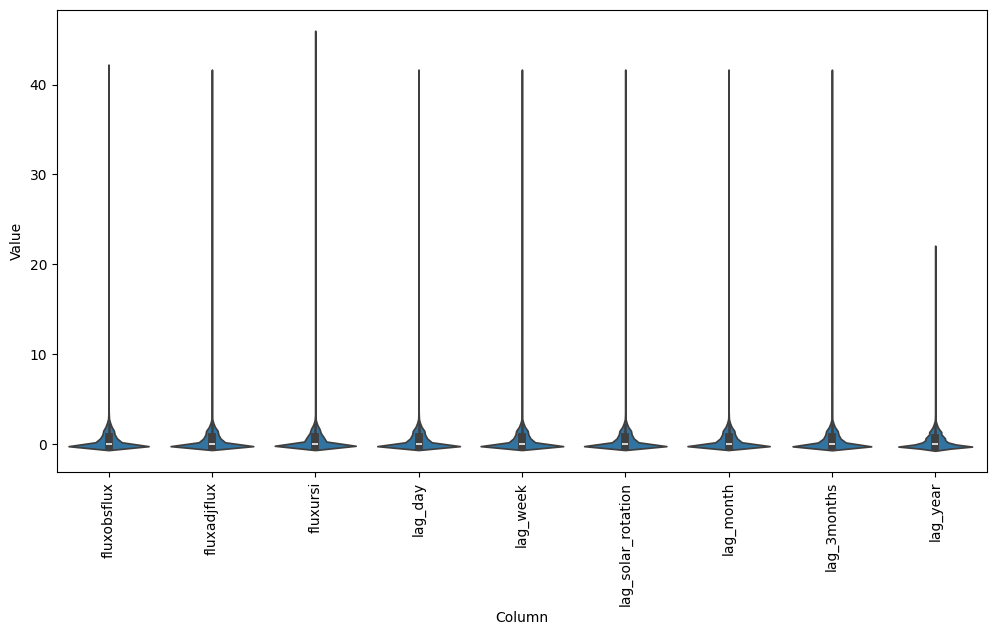

In [ ]:
df_plot = train_df[features].melt(
    var_name="Column",
    value_name="Value"
)

plt.figure(figsize=(12,6))

sns.violinplot(
    x="Column",
    y="Value",
    data=df_plot
)

plt.xticks(rotation=90)

plt.show()

Las correlaciones más importantes son entre [fluxobs, fluxadj, fluxursi] y [lag_day, lag_solar_rotation]

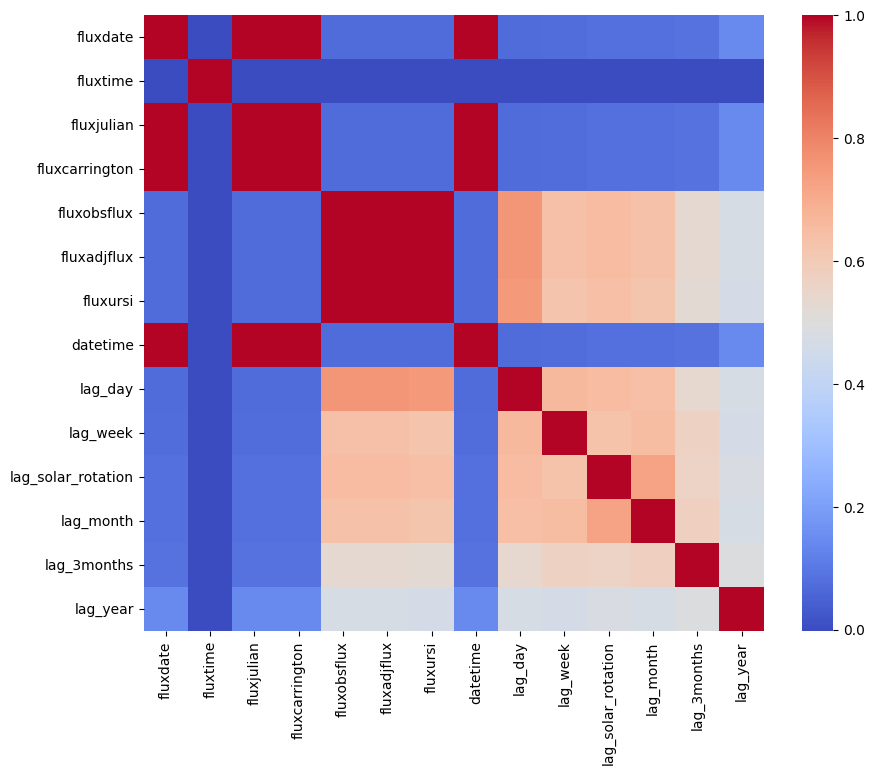

In [ ]:
corr = train_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr, cmap="coolwarm")

plt.show()

Los datos no cambian en tendencia, solo en estándar.

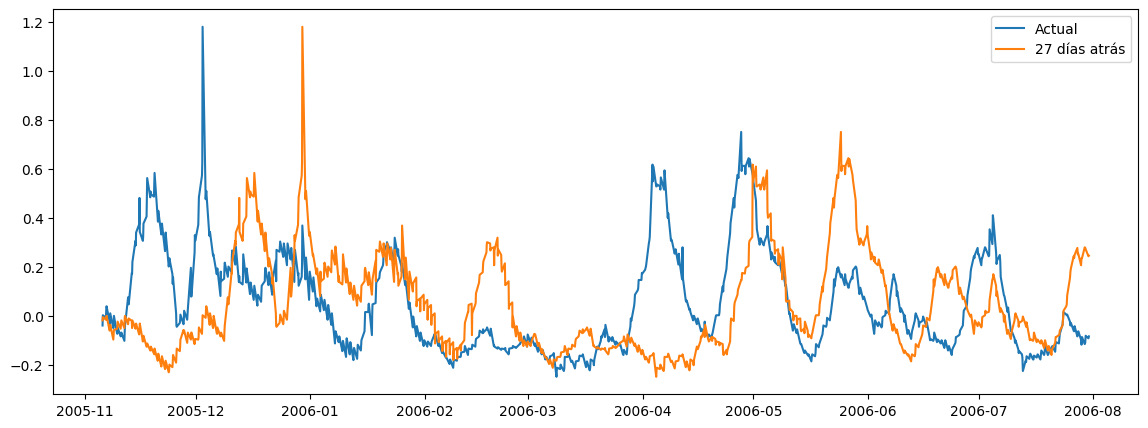

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(train_df["datetime"][:800], train_df["fluxadjflux"][:800], label="Actual")
plt.plot(train_df["datetime"][:800], train_df["lag_solar_rotation"][:800],
         label="27 días atrás")

plt.legend()
plt.show()

In [ ]:


# Data Preparation  ---

# Assuming flux_path is defined from a previous cell. If not, uncomment and define it:
flux_path = '/content/drive/MyDrive/solarFlux/solar_flux_table.txt'

df = pd.read_csv(flux_path,
            sep=r"\s+",          # separa por múltiples espacios
            skiprows=[1])     # ignora la línea de guiones)

cols = [
    "fluxjulian",
    "fluxcarrington",
    "fluxobsflux",
    "fluxadjflux",
    "fluxursi"
]
df[cols] = df[cols].astype(float)

df["fluxdate"] = pd.to_datetime(
    df["fluxdate"].astype(str),
    format="%Y%m%d"
)

df["datetime"] = pd.to_datetime(
    df["fluxdate"].dt.strftime("%Y-%m-%d") +
    " " +
    df["fluxtime"].astype(str).str.zfill(6),
    format="%Y-%m-%d %H%M%S"
)

# Create lags
df["lag_day"] = df["fluxadjflux"].shift(3)
df["lag_week"] = df["fluxadjflux"].shift(21)
df["lag_solar_rotation"] = df["fluxadjflux"].shift(81)
df["lag_month"] = df["fluxadjflux"].shift(90)
df["lag_3months"] = df["fluxadjflux"].shift(270) # Corrected typo here
df["lag_year"] = df["fluxadjflux"].shift(1095)

# Eliminar NaNs generados por los lags
df = df.dropna().reset_index(drop=True)

# Data Splitting
n = len(df)
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

# Normalization
features = [
    "fluxobsflux",
    "fluxadjflux",
    "fluxursi",
    "lag_day",
    "lag_week",
    "lag_solar_rotation",
    "lag_month",
    "lag_3months",
    "lag_year"
]
scaler = RobustScaler()

train_df[features] = scaler.fit_transform(train_df[features])

val_df[features] = scaler.transform(val_df[features])

test_df[features] = scaler.transform(test_df[features])



# Definir history and target sizes
history_size = 3 # Changed to 3, taking the daily 3 takes on the data
target_size = 1  # Predict 1 step into the future

# Preparar data para LSTM


features_for_lstm = [
    "fluxobsflux",
    "fluxadjflux",
    "fluxursi",
    "lag_day",
    "lag_week",
    "lag_solar_rotation",
    "lag_month",
    "lag_3months",
    "lag_year"
]

# Get the index of 'fluxadjflux' in the features_for_lstm list
target_feature_index = features_for_lstm.index('fluxadjflux')

def create_sequences_with_target_index(data, history_size, target_size, target_idx):
    X = []
    y = []
    for i in range(len(data) - history_size - target_size + 1):
        X.append(data[i:(i + history_size), :])
        y.append(data[i + history_size + target_size - 1, target_idx])
    return np.array(X), np.array(y)



# Create sequences for the first model
x_train_scaled, y_train_scaled = create_sequences_with_target_index(
    train_df[features_for_lstm].values,
    history_size,
    target_size,
    target_feature_index
)

print(f"x_train_scaled shape: {x_train_scaled.shape}")
print(f"y_train_scaled shape: {y_train_scaled.shape}")


x_train_scaled shape: (15746, 3, 9)
y_train_scaled shape: (15746,)


/tmp/ipykernel_21540/340197200.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[features] = scaler.fit_transform(train_df[features])
/tmp/ipykernel_21540/340197200.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df[features] = scaler.transform(val_df[features])
/tmp/ipykernel_21540/340197200.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

Model 1 - x_train_scaled shape: (15746, 3, 9)
Model 1 - y_train_scaled shape: (15746,)
Epoch 1/600


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.2014 - mae: 0.0904 - rmse: 0.4487 - val_loss: 0.1166 - val_mae: 0.0990 - val_rmse: 0.3415
Epoch 2/600
493/493 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1792 - mae: 0.0676 - rmse: 0.4233 - val_loss: 0.1134 - val_mae: 0.0919 - val_rmse: 0.3367
Epoch 3/600
493/493 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1766 - mae: 0.0639 - rmse: 0.4203 - val_loss: 0.1176 - val_mae: 0.0984 - val_rmse: 0.3430
Epoch 4/600
493/493 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1766 - mae: 0.0625 - rmse: 0.4202 - val_loss: 0.1178 - val_mae: 0.0957 - val_rmse: 0.3432
Epoch 5/600
493/493 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1751 - mae: 0.0609 - rmse: 0.4185 - val_loss: 0.1196 - val_mae: 0.1178 - val_rmse: 0.3459
Epoch 6/600
493/493 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1747 - mae: 0.0605 - rmse: 0.4179 - val_loss: 0.1263 - val_mae: 0.1170 - val_rmse: 0.3554
Epoch 7/600
493/493 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1748 - mae: 0.0620 - rmse: 0.41

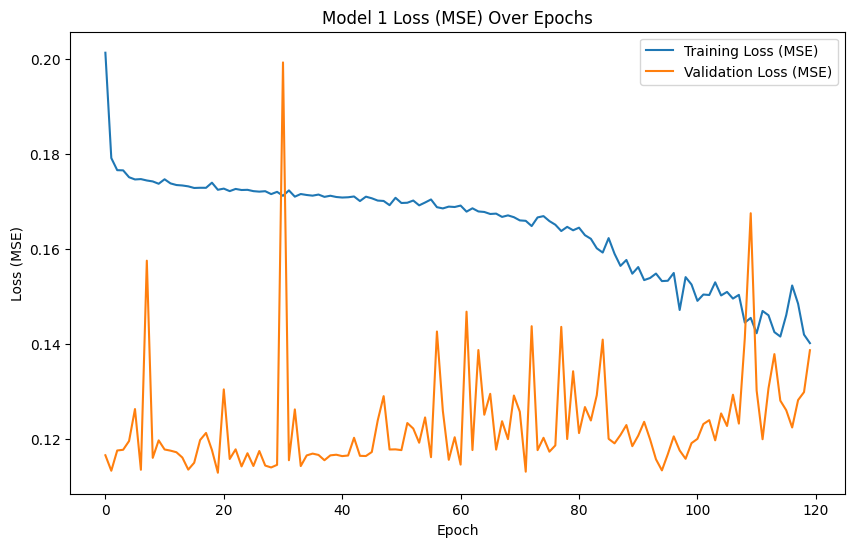

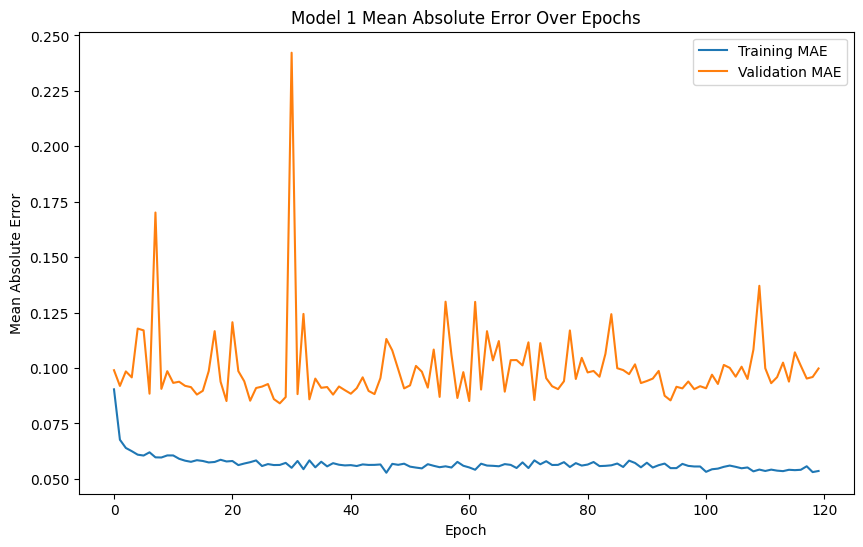

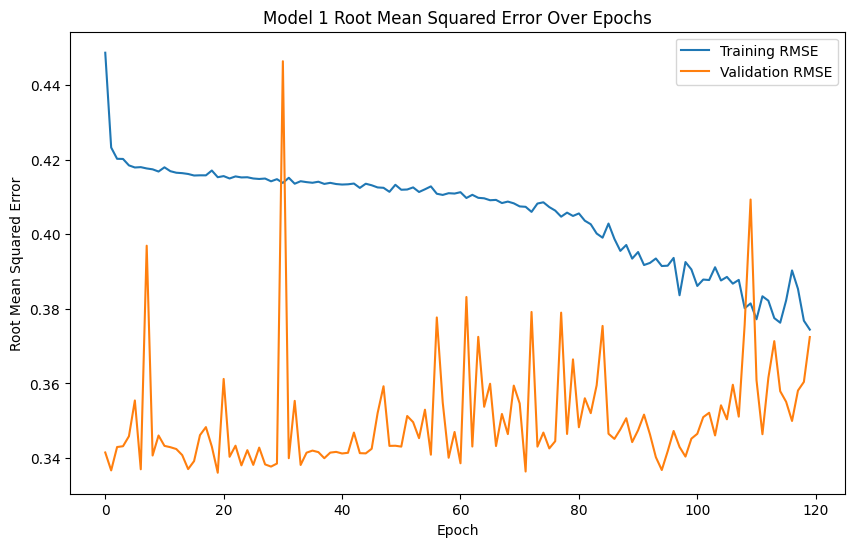

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# --- Primer Modelo (history_size = 3) ---

history_size_model1 = 3
target_size = 1

# Preparar datos
x_train_scaled_model1, y_train_scaled_model1 = create_sequences_with_target_index(
    train_df[features_for_lstm].values,
    history_size_model1,
    target_size,
    target_feature_index
)
x_val_scaled_model1, y_val_scaled_model1 = create_sequences_with_target_index(
    val_df[features_for_lstm].values,
    history_size_model1,
    target_size,
    target_feature_index
)
x_test_scaled_model1, y_test_scaled_model1 = create_sequences_with_target_index(
    test_df[features_for_lstm].values,
    history_size_model1,
    target_size,
    target_feature_index
)

print(f"Model 1 - x_train_scaled shape: {x_train_scaled_model1.shape}")
print(f"Model 1 - y_train_scaled shape: {y_train_scaled_model1.shape}")

# Declaración de LSTM con Dropout
model1 = keras.Sequential([
    layers.LSTM(50, activation='relu', input_shape=(x_train_scaled_model1.shape[1], x_train_scaled_model1.shape[2])),
    layers.Dense(1)
])

# Compilar MSE, MAE y RMSE
optimizer1 = keras.optimizers.Adam(learning_rate=0.001)
model1.compile(optimizer=optimizer1, loss='mse', metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')])

# Define Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=100,
    restore_best_weights=True
)

# Entrenamiento
history1 = model1.fit(
    x_train_scaled_model1,
    y_train_scaled_model1,
    epochs=600,
    validation_data=(x_val_scaled_model1, y_val_scaled_model1),
    batch_size=32,
    verbose=1,
    callbacks=[early_stopping] # Add early stopping here
)

print("First LSTM model training complete!")

# Evaluación de TEST
test_results_model1 = model1.evaluate(x_test_scaled_model1, y_test_scaled_model1, verbose=0)

# Plot training history (Loss) for Model 1
plt.figure(figsize=(10, 6))
plt.plot(history1.history['loss'], label='Training Loss (MSE)')
plt.plot(history1.history['val_loss'], label='Validation Loss (MSE)')
#plt.axhline(y=test_results_model1[0], color='r', linestyle='--', label=f'Test Loss (MSE): {test_results_model1[0]:.4f}')
plt.title('Model 1 Loss (MSE) Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

# Plot training history (MAE) for Model 1
plt.figure(figsize=(10, 6))
plt.plot(history1.history['mae'], label='Training MAE')
plt.plot(history1.history['val_mae'], label='Validation MAE')
#plt.axhline(y=test_results_model1[1], color='r', linestyle='--', label=f'Test MAE: {test_results_model1[1]:.4f}')
plt.title('Model 1 Mean Absolute Error Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

# Plot training history (RMSE) for Model 1
plt.figure(figsize=(10, 6))
plt.plot(history1.history['rmse'], label='Training RMSE')
plt.plot(history1.history['val_rmse'], label='Validation RMSE')
#plt.axhline(y=test_results_model1[2], color='r', linestyle='--', label=f'Test RMSE: {test_results_model1[2]:.4f}')
plt.title('Model 1 Root Mean Squared Error Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Root Mean Squared Error')
plt.legend()
plt.show()

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


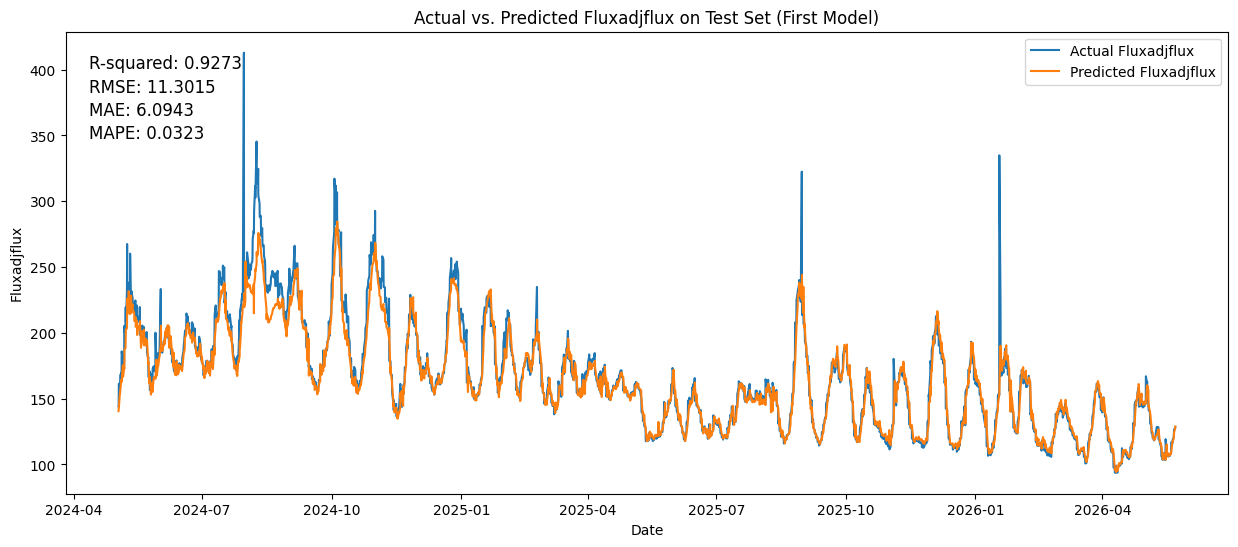


--- Metrics for First Model ---
Mean Squared Error on Test Set: 127.7242
Root Mean Squared Error on Test Set: 11.3015
Mean Absolute Error on Test Set: 6.0943
Mean Absolute Percentage Error on Test Set: 0.0323
R-squared on Test Set: 0.9273


In [ ]:
# Predicciones Modelo 1
test_predictions_model1 = model1.predict(x_test_scaled_model1).flatten()

# Create a dummy array with zeros for all features, then place y_test_scaled at the target_feature_index
dummy_y_test_model1 = np.zeros((len(y_test_scaled_model1), len(features)))
dummy_y_test_model1[:, target_feature_index] = y_test_scaled_model1
actual_fluxadjflux_model1 = scaler.inverse_transform(dummy_y_test_model1)[:, target_feature_index]

dummy_predictions_model1 = np.zeros((len(test_predictions_model1), len(features)))
dummy_predictions_model1[:, target_feature_index] = test_predictions_model1
predicted_fluxadjflux_model1 = scaler.inverse_transform(dummy_predictions_model1)[:, target_feature_index]

# Plot actual vs. predicted values for Model 1
plt.figure(figsize=(15, 6))
plt.plot(df['datetime'][len(train_df) + len(val_df) + history_size_model1 - 1:].head(len(actual_fluxadjflux_model1)), actual_fluxadjflux_model1, label='Actual Fluxadjflux')
plt.plot(df['datetime'][len(train_df) + len(val_df) + history_size_model1 - 1:].head(len(predicted_fluxadjflux_model1)), predicted_fluxadjflux_model1, label='Predicted Fluxadjflux')
plt.title('Actual vs. Predicted Fluxadjflux on Test Set (First Model)')
plt.xlabel('Date')
plt.ylabel('Fluxadjflux')
plt.legend()

# Calculate metrics for Model 1
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

mse1 = mean_squared_error(actual_fluxadjflux_model1, predicted_fluxadjflux_model1)
mae1 = mean_absolute_error(actual_fluxadjflux_model1, predicted_fluxadjflux_model1)
rmse1 = np.sqrt(mse1)
r2_1 = r2_score(actual_fluxadjflux_model1, predicted_fluxadjflux_model1)
mape1 = mean_absolute_percentage_error(actual_fluxadjflux_model1, predicted_fluxadjflux_model1)

# Add R-squared, RMSE, MAE, and MAPE values to the plot for Model 1
plt.text(0.02, 0.95, f'R-squared: {r2_1:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.text(0.02, 0.90, f'RMSE: {rmse1:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.text(0.02, 0.85, f'MAE: {mae1:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.text(0.02, 0.80, f'MAPE: {mape1:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

plt.show()

print(f"\n--- Metrics for First Model ---")
print(f"Mean Squared Error on Test Set: {mse1:.4f}")
print(f"Root Mean Squared Error on Test Set: {rmse1:.4f}")
print(f"Mean Absolute Error on Test Set: {mae1:.4f}")
print(f"Mean Absolute Percentage Error on Test Set: {mape1:.4f}")
print(f"R-squared on Test Set: {r2_1:.4f}")

In [ ]:
# @title
model1.save('model1.h5')

from google.colab import files
files.download('model1.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf # Required for loading Keras model
from sklearn.preprocessing import RobustScaler # Required for scaler

# --- Re-initialize Data and Model Loading for self-contained cell ---

# Define flux_path (assuming it's in MyDrive as seen in previous cells)
flux_path = '/content/fluxtable.txt'

# Load data
df = pd.read_csv(flux_path,
            sep=r"\s+",          # separa por múltiples espacios
            skiprows=[1])     # ignora la línea de guiones)

# Convert numerical columns
cols = [
    "fluxjulian",
    "fluxcarrington",
    "fluxobsflux",
    "fluxadjflux",
    "fluxursi"
]
df[cols] = df[cols].astype(float)

# Convert fluxdate
df["fluxdate"] = pd.to_datetime(
    df["fluxdate"].astype(str),
    format="%Y%m%d"
)

# Convert fluxtime to datetime
df["datetime"] = pd.to_datetime(
    df["fluxdate"].dt.strftime("%Y-%m-%d") +
    " " +
    df["fluxtime"].astype(str).str.zfill(6),
    format="%Y-%m-%d %H%M%S"
)

# Create lags
df["lag_day"] = df["fluxadjflux"].shift(3)
df["lag_week"] = df["fluxadjflux"].shift(21)
df["lag_solar_rotation"] = df["fluxadjflux"].shift(81)
df["lag_month"] = df["fluxadjflux"].shift(90)
df["lag_3months"] = df["fluxadjflux"].shift(270)
df["lag_year"] = df["fluxadjflux"].shift(1095)

# Eliminar NaNs generados por los lags
df = df.dropna().reset_index(drop=True)

# Data Splitting
n = len(df)
train_df = df[0:int(n*0.7)].copy() # 70% for training
# The remaining 30% of the data will be used as the 'custom_prediction_df'
# This combines what was previously val_df and test_df
custom_prediction_df = df[int(n*0.7):].copy()

# Normalization setup
features = [
    "fluxobsflux",
    "fluxadjflux",
    "fluxursi",
    "lag_day",
    "lag_week",
    "lag_solar_rotation",
    "lag_month",
    "lag_3months",
    "lag_year"
]
scaler = RobustScaler()

# Fit scaler only on train_df and transform all dataframes
train_df_scaled = train_df[features].copy()
custom_prediction_df_scaled = custom_prediction_df[features].copy() # Scaled version of the custom dataset

train_df_scaled[features] = scaler.fit_transform(train_df_scaled[features])
custom_prediction_df_scaled[features] = scaler.transform(custom_prediction_df_scaled[features])

# Define history and target sizes (from model training cell 'e2c222fc')
history_size_model1 = 3
target_size = 1

features_for_lstm = features # All features are used in the LSTM input
target_feature_index = features_for_lstm.index('fluxadjflux')

# Function to create sequences (from model training cell 'IJqC-u0_iXMU')
def create_sequences_with_target_index(data, history_size, target_size, target_idx):
    X = []
    y = []
    for i in range(len(data) - history_size - target_size + 1):
        X.append(data[i:(i + history_size), :])
        y.append(data[i + history_size + target_size - 1, target_idx])
    return np.array(X), np.array(y)

# Create sequences for the custom prediction dataset (formerly test)
x_custom_scaled, y_custom_scaled = create_sequences_with_target_index(
    custom_prediction_df_scaled[features_for_lstm].values,
    history_size_model1,
    target_size,
    target_feature_index
)

# Load Model 1 from file as requested by the user
model1_path = '/content/model1.h5' # Corrected path to the model file

# Define custom objects for loading the model
# This addresses the ValueError when deserializing metrics/losses
custom_objects = {
    'mse': tf.keras.metrics.MeanSquaredError, # Explicitly map 'mse' string to the MeanSquaredError *metric* class
    'mae': tf.keras.metrics.MeanAbsoluteError, # For the MAE metric
    'rmse': tf.keras.metrics.RootMeanSquaredError # For the custom RMSE metric
}

try:
    # Pass custom_objects to load_model
    model1 = tf.keras.models.load_model(model1_path, custom_objects=custom_objects)
    print(f"Successfully loaded model from {model1_path}")
except Exception as e:
    print(f"Error loading model from {model1_path}: {e}")
    print("Model loading failed. Please ensure the model file exists and is compatible.")
    raise SystemExit("Model loading failed. Cannot proceed with predictions.")


# Make predictions with the loaded model on the custom dataset
custom_predictions = model1.predict(x_custom_scaled).flatten()

# Inverse transform predictions and actual values to original scale for custom dataset
dummy_y_custom = np.zeros((len(y_custom_scaled), len(features)))
dummy_y_custom[:, target_feature_index] = y_custom_scaled
actual_fluxadjflux_custom = scaler.inverse_transform(dummy_y_custom)[:, target_feature_index]

dummy_predictions_custom = np.zeros((len(custom_predictions), len(features)))
dummy_predictions_custom[:, target_feature_index] = custom_predictions
predicted_fluxadjflux_custom = scaler.inverse_transform(dummy_predictions_custom)[:, target_feature_index]


# --- Interactive Interface Code ---

# The actual_fluxadjflux_custom starts its predictions corresponding to an offset within the custom_prediction_df.
# This offset is `history_size_model1 + target_size - 1`.
custom_prediction_df_start_offset = history_size_model1 + target_size - 1

# Create a DataFrame containing only the datetimes for which we have custom predictions
# and map them to their relative indices in the actual/predicted arrays
prediction_dates_df = pd.DataFrame({
    'datetime': custom_prediction_df['datetime'].iloc[custom_prediction_df_start_offset:].values,
    'relative_idx': np.arange(len(actual_fluxadjflux_custom))
})
prediction_dates_df['date'] = prediction_dates_df['datetime'].dt.date

# Create a DatePicker widget
# Limit the calendar to the requested dates by the user
start_date = datetime.strptime('2024-05-02', '%Y-%m-%d').date()
end_date = datetime.strptime('2026-05-22', '%Y-%m-%d').date()

date_picker = widgets.DatePicker(
    description='Pick a Date for Prediction',
    disabled=False,
    # Ensure default value is within the specified min/max and available prediction dates
    value=max(start_date, prediction_dates_df['date'].min()) if not prediction_dates_df.empty and prediction_dates_df['date'].min() <= end_date else start_date,
    min=start_date,
    max=end_date
)

# Output widget to display results
output = widgets.Output()

def on_date_change(change):
    with output:
        clear_output(wait=True)
        selected_date = change.new

        if selected_date is None:
            print("Please select a date.")
            return

        # Filter all predictions for the selected date within the custom dataset
        daily_predictions = prediction_dates_df[prediction_dates_df['date'] == selected_date].copy()

        if daily_predictions.empty:
            print(f"No predictions available for {selected_date}. Please select a date within the custom prediction range.")
            return

        print(f"--- Predictions for Date: {selected_date} (Custom Dataset) ---")

        # Store all results for this day for plotting
        daily_actuals = []
        daily_predicteds = []
        daily_datetimes = []
        daily_abs_errors = []
        daily_squared_errors = []

        for _, row in daily_predictions.iterrows():
            k_index = int(row['relative_idx']) # Ensure index is integer
            current_datetime = row['datetime']

            actual_val = actual_fluxadjflux_custom[k_index] # Use custom actuals
            predicted_val = predicted_fluxadjflux_custom[k_index] # Use custom predictions

            abs_error = np.abs(actual_val - predicted_val)
            squared_error = (actual_val - predicted_val)**2

            daily_actuals.append(actual_val)
            daily_predicteds.append(predicted_val)
            daily_datetimes.append(current_datetime)
            daily_abs_errors.append(abs_error)
            daily_squared_errors.append(squared_error)

            print(f"\nTimestamp: {current_datetime.strftime('%H:%M:%S')}")
            print(f"  Actual Fluxadjflux: {actual_val:.4f}")
            print(f"  Predicted Fluxadjflux: {predicted_val:.4f}")
            print(f"  Absolute Error: {abs_error:.4f}")
            print(f"  Squared Error: {squared_error:.4f}")

        # Plotting context for the day
        plt.figure(figsize=(15, 6))

        # Plot all actual and predicted values for the selected day
        plt.plot(daily_datetimes, daily_actuals, 'o-', label='Actual Fluxadjflux (Day)', color='blue')
        plt.plot(daily_datetimes, daily_predicteds, 'x--', label='Predicted Fluxadjflux (Day)', color='red')

        # Add title and labels
        plt.title(f'Actual vs. Predicted Fluxadjflux for {selected_date} (Model 1 - Custom Dataset)')
        plt.xlabel('Time of Day')
        plt.ylabel('Fluxadjflux')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # Overall daily metrics (if multiple predictions exist for the day)
        if len(daily_predictions) > 0:
            daily_mse = np.mean(daily_squared_errors)
            daily_mae = np.mean(daily_abs_errors)
            print(f"\n--- Daily Aggregate Metrics for {selected_date} (Custom Dataset) ---")
            print(f"Daily Mean Squared Error: {daily_mse:.4f}")
            print(f"Daily Mean Absolute Error: {daily_mae:.4f}")

# Link the date picker to the handler function
date_picker.observe(on_date_change, names='value')

# Display the widgets
display(date_picker, output)

Successfully loaded model from /content/model1.h5
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


DatePicker(value=datetime.date(2024, 5, 2), description='Pick a Date for Prediction')

Output()